In [1]:
import zipfile
import pandas as pd
import os
from pathlib import Path

#cоздаем папку для тестовых данных
test_dir = Path('celeba_test')
test_dir.mkdir(exist_ok=True)

archive_path = 'arch.zip'

#файлы, которые нам нужны из архива
files_to_extract = [
    'list_bbox_celeba.csv',
    'list_landmarks_align_celeba.csv', 
    'list_attr_celeba.csv',
    'list_eval_partition.csv'
]

with zipfile.ZipFile(archive_path, 'r') as zip_ref:
    #распаковываем все CSV файлы
    for file in files_to_extract:
        try:
            zip_ref.extract(file, test_dir)
            print(f"Распакован: {file}")
        except KeyError:
            print(f"Файл не найден: {file}")

Распакован: list_bbox_celeba.csv
Распакован: list_landmarks_align_celeba.csv
Распакован: list_attr_celeba.csv
Распакован: list_eval_partition.csv


In [2]:
import zipfile
import matplotlib.pyplot as plt
import cv2
import numpy as np
import os


num_of_images=100
with zipfile.ZipFile('arch.zip', 'r') as zip_ref:
    all_files = zip_ref.namelist()
    selected = [f for f in all_files if f.endswith('.jpg')][:num_of_images]
    
    images = []
    names = []
    
    for img_path in selected:
        with zip_ref.open(img_path) as file:
            img_data = np.frombuffer(file.read(), np.uint8)
            img = cv2.cvtColor(cv2.imdecode(img_data, cv2.IMREAD_COLOR), cv2.COLOR_BGR2RGB)
            images.append(img)
            names.append(os.path.basename(img_path))

def show_img(idx):
    if 0 <= idx < len(images):
        plt.figure(figsize=(8, 6))
        plt.imshow(images[idx])
        plt.title(f"{idx}: {names[idx]}")
        plt.axis('off')
        plt.show()
    else:
        print(f"Индекс {idx} вне диапазона (0-{len(images)-1})")

print(f"Загружено {len(images)} фото: {names}")

Загружено 100 фото: ['000001.jpg', '000002.jpg', '000003.jpg', '000004.jpg', '000005.jpg', '000006.jpg', '000007.jpg', '000008.jpg', '000009.jpg', '000010.jpg', '000011.jpg', '000012.jpg', '000013.jpg', '000014.jpg', '000015.jpg', '000016.jpg', '000017.jpg', '000018.jpg', '000019.jpg', '000020.jpg', '000021.jpg', '000022.jpg', '000023.jpg', '000024.jpg', '000025.jpg', '000026.jpg', '000027.jpg', '000028.jpg', '000029.jpg', '000030.jpg', '000031.jpg', '000032.jpg', '000033.jpg', '000034.jpg', '000035.jpg', '000036.jpg', '000037.jpg', '000038.jpg', '000039.jpg', '000040.jpg', '000041.jpg', '000042.jpg', '000043.jpg', '000044.jpg', '000045.jpg', '000046.jpg', '000047.jpg', '000048.jpg', '000049.jpg', '000050.jpg', '000051.jpg', '000052.jpg', '000053.jpg', '000054.jpg', '000055.jpg', '000056.jpg', '000057.jpg', '000058.jpg', '000059.jpg', '000060.jpg', '000061.jpg', '000062.jpg', '000063.jpg', '000064.jpg', '000065.jpg', '000066.jpg', '000067.jpg', '000068.jpg', '000069.jpg', '000070.jpg',

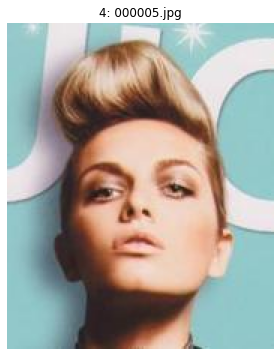

In [3]:
show_img(4)

In [9]:
type(images[5])

numpy.ndarray

In [3]:
import sys

!{sys.executable} -m pip uninstall mediapipe -y

!{sys.executable} -m pip install mediapipe==0.10.8

print("Установлена старая версия mediapipe")
print("Перезапустите ядро (Kernel -> Restart)")

✅ Установлена старая версия mediapipe
🔄 Перезапустите ядро (Kernel -> Restart)


 Название файла: 000089.jpg

 Время обработки (RGB): 123.75 мс
 Время обработки (BGR): 10.99 мс
 Используем формат: RGB
 Найдено лиц: 1
 Лиц с уверенностью >0.7: 1

 Лицо 1: уверенность 0.914
   Координаты: x=46, y=78, w=99, h=99


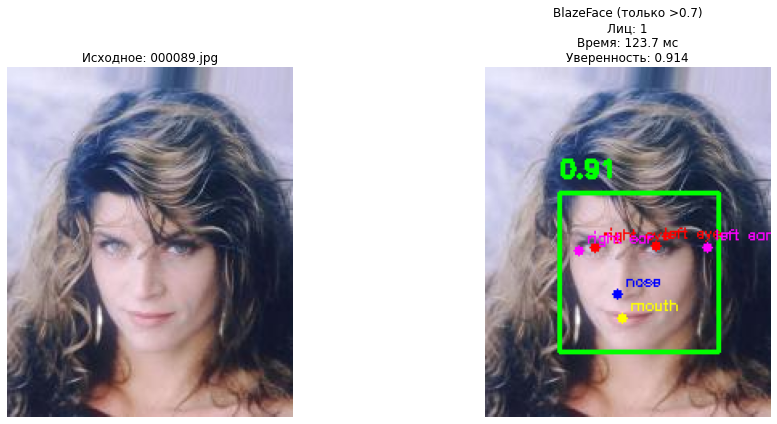


 Детальная статистика:
  - Формат изображения: RGB
  - Время обработки: 123.75 мс
  - Лицо 1: уверенность 0.914


In [3]:
import mediapipe as mp
import cv2
import numpy as np
import matplotlib.pyplot as plt
import time
from pathlib import Path

img = images[88]
img_name = names[88]

print(f" Название файла: {img_name}")

mp_face_detection = mp.solutions.face_detection
face_detection = mp_face_detection.FaceDetection(
    model_selection=0,
    min_detection_confidence=0.7
)

def test_blazeface_on_image(image, image_name):
    annotated_image = image.copy()
    
    start_time = time.time()
    results = face_detection.process(image)
    time1 = (time.time() - start_time) * 1000
    
    image_bgr = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)
    start_time = time.time()
    results_bgr = face_detection.process(image_bgr)
    time2 = (time.time() - start_time) * 1000
    
    print(f"\n Время обработки (RGB): {time1:.2f} мс")
    print(f" Время обработки (BGR): {time2:.2f} мс")
    
    if results.detections:
        used_results = results
        used_format = "RGB"
        used_time = time1
    elif results_bgr.detections:
        used_results = results_bgr
        used_format = "BGR"
        used_time = time2
    else:
        print(" Лица не обнаружены ни в одном формате")
        return None, None, None
    
    print(f" Используем формат: {used_format}")
    print(f" Найдено лиц: {len(used_results.detections)}")
    
    h, w, _ = image.shape
    
    # фильтруем detections с уверенностью > 0.7
    filtered_detections = [d for d in used_results.detections if d.score[0] > 0.7]
    print(f" Лиц с уверенностью >0.7: {len(filtered_detections)}")
    
    for i, detection in enumerate(filtered_detections):
        confidence = detection.score[0]
        print(f"\n Лицо {i+1}: уверенность {confidence:.3f}")
        
        bbox = detection.location_data.relative_bounding_box
        x = int(bbox.xmin * w)
        y = int(bbox.ymin * h)
        width = int(bbox.width * w)
        height = int(bbox.height * h)
        
        print(f"   Координаты: x={x}, y={y}, w={width}, h={height}")
        
        cv2.rectangle(annotated_image, (x, y), (x + width, y + height), (0, 255, 0), 2)
        cv2.putText(annotated_image, f"{confidence:.2f}", (x, y-10), 
                   cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)
        
        keypoints = []
        for j in range(6):
            keypoint = detection.location_data.relative_keypoints[j]
            kp_x = int(keypoint.x * w)
            kp_y = int(keypoint.y * h)
            keypoints.append((kp_x, kp_y))
            
            colors = [(255,0,0), (255,0,0), (0,0,255), (255,255,0), (255,0,255), (255,0,255)]
            cv2.circle(annotated_image, (kp_x, kp_y), 3, colors[j], -1)
        
        keypoint_names = ['right eye', 'left eye', 'nose', 'mouth', 'right ear', 'left ear']
        for j, (kp, name) in enumerate(zip(keypoints, keypoint_names)):
            cv2.putText(annotated_image, name, (kp[0]+5, kp[1]-5), 
                       cv2.FONT_HERSHEY_SIMPLEX, 0.3, colors[j], 1)
    
    stats = {
        'num_faces': len(filtered_detections),
        'inference_time_ms': used_time,
        'confidences': [d.score[0] for d in filtered_detections],
        'format': used_format
    }
    
    return annotated_image, stats, filtered_detections



result_img, stats, results = test_blazeface_on_image(img, img_name)

if result_img is not None:
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    axes[0].imshow(img)
    axes[0].set_title(f"Исходное: {img_name}")
    axes[0].axis('off')
    
    axes[1].imshow(result_img)
    conf_str = ', '.join([f'{c:.3f}' for c in stats['confidences']])
    axes[1].set_title(f"BlazeFace (только >0.7)\nЛиц: {stats['num_faces']}\nВремя: {stats['inference_time_ms']:.1f} мс\nУверенность: {conf_str}")
    axes[1].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    print("\n Детальная статистика:")
    print(f"  - Формат изображения: {stats['format']}")
    print(f"  - Время обработки: {stats['inference_time_ms']:.2f} мс")
    for i, conf in enumerate(stats['confidences']):
        print(f"  - Лицо {i+1}: уверенность {conf:.3f}")

ПРОВЕРИМ МЕТРИКИ PRECISION И RECALL для лендмарков лица

In [4]:
gt_df = pd.read_csv('celeba_test/list_landmarks_align_celeba.csv')

mp_face_detection = mp.solutions.face_detection
face_detection = mp_face_detection.FaceDetection(model_selection=0, min_detection_confidence=0.5)

RADIUS = 10

total_tp = total_fp = total_fn = 0

for img, img_name in zip(images, names):
    gt = gt_df[gt_df['image_id'] == img_name].iloc[0]
    gt_points = [
        (gt['lefteye_x'], gt['lefteye_y']),
        (gt['righteye_x'], gt['righteye_y']),
        (gt['nose_x'], gt['nose_y'])
    ]
    
    #проверка двух форматов
    results_rgb = face_detection.process(img)
    results_bgr = face_detection.process(cv2.cvtColor(img, cv2.COLOR_RGB2BGR))
    
    if results_rgb.detections:
        results = results_rgb
    elif results_bgr.detections:
        results = results_bgr
    else:
        total_fn += 3
        continue
    
    h, w, _ = img.shape
    
    tp = fp = 0
    found_gt = [False] * 3
    
    for d in results.detections:
        for j in range(3):
            kp = d.location_data.relative_keypoints[j]
            pred = (int(kp.x * w), int(kp.y * h))
            
            matched = False
            for i, gt_pt in enumerate(gt_points):
                if not found_gt[i]:
                    dist = np.sqrt((pred[0]-gt_pt[0])**2 + (pred[1]-gt_pt[1])**2)
                    if dist <= RADIUS:
                        tp += 1
                        found_gt[i] = True
                        matched = True
                        break
            if not matched:
                fp += 1
    
    fn = found_gt.count(False)
    
    total_tp += tp
    total_fp += fp
    total_fn += fn

p = total_tp/(total_tp+total_fp) if total_tp+total_fp else 0
r = total_tp/(total_tp+total_fn) if total_tp+total_fn else 0
f1 = 2*p*r/(p+r) if p+r else 0

print(f"Всего изображений: {len(images)}")
print(f"TP: {total_tp}, FP: {total_fp}, FN: {total_fn}")
print(f"Precision: {p:.3f}")
print(f"Recall: {r:.3f}")
print(f"F1-score: {f1:.3f}")

Всего изображений: 100
TP: 297, FP: 9, FN: 3
Precision: 0.971
Recall: 0.990
F1-score: 0.980


 Название файла: 000055.jpg
 Размер: 178x218
✅ Найдено лиц: 1
   Всего точек: 468


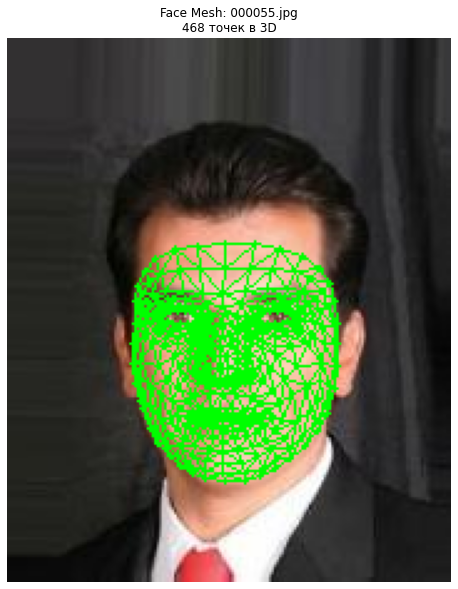


📊 Первые 10 точек (в пикселях):
--------------------------------------------------
Точка   0: x=  85, y= 148, z=-0.0538
Точка   1: x=  85, y= 136, z=-0.1088
Точка   2: x=  85, y= 139, z=-0.0554
Точка   3: x=  82, y= 123, z=-0.0812
Точка   4: x=  85, y= 132, z=-0.1164
Точка   5: x=  85, y= 127, z=-0.1090
Точка   6: x=  86, y= 114, z=-0.0573
Точка   7: x=  62, y= 113, z=0.0424
Точка   8: x=  86, y= 107, z=-0.0452
Точка   9: x=  86, y= 102, z=-0.0506


In [8]:
import mediapipe as mp
import cv2
import numpy as np
import matplotlib.pyplot as plt

#инициализация Face Mesh
mp_face_mesh = mp.solutions.face_mesh
face_mesh = mp_face_mesh.FaceMesh(
    static_image_mode=True,
    max_num_faces=1,
    min_detection_confidence=0.5
)

img = images[54]
img_name = names[54]
h, w, _ = img.shape

print(f" Название файла: {img_name}")
print(f" Размер: {w}x{h}")

results = face_mesh.process(cv2.cvtColor(img, cv2.COLOR_RGB2BGR))

#визуализация
annotated_image = img.copy()

if results.multi_face_landmarks:
    print(f"✅ Найдено лиц: {len(results.multi_face_landmarks)}")
    print(f"   Всего точек: 468")
    
    for face_landmarks in results.multi_face_landmarks:
        #рисуем все 468 точек
        for landmark in face_landmarks.landmark:
            x = int(landmark.x * w)
            y = int(landmark.y * h)
            cv2.circle(annotated_image, (x, y), 1, (0, 255, 0), -1)
        
        #рисуем соединения между точками
        for connection in mp_face_mesh.FACEMESH_TESSELATION:
            start = face_landmarks.landmark[connection[0]]
            end = face_landmarks.landmark[connection[1]]
            x1, y1 = int(start.x * w), int(start.y * h)
            x2, y2 = int(end.x * w), int(end.y * h)
            cv2.line(annotated_image, (x1, y1), (x2, y2), (0, 255, 0), 1)
else:
    print("Лица не обнаружены")

#показываем результат
plt.figure(figsize=(15, 10))
plt.imshow(annotated_image)
plt.title(f"Face Mesh: {img_name}\n468 точек в 3D")
plt.axis('off')
plt.show()

#выводим пример координат первых 10 точек в пикселях
if results.multi_face_landmarks:
    print("\n📊 Первые 10 точек (в пикселях):")
    print("-" * 50)
    for i, landmark in enumerate(results.multi_face_landmarks[0].landmark[:10]):
        x_px = int(landmark.x * w)
        y_px = int(landmark.y * h)
        print(f"Точка {i:3d}: x={x_px:4d}, y={y_px:4d}, z={landmark.z:.4f}")

In [19]:
import mediapipe as mp
import cv2
from pathlib import Path
from IPython.display import Video as IPythonVideo

#инициализация Face Mesh для нескольких лиц
mp_face_mesh = mp.solutions.face_mesh
face_mesh = mp_face_mesh.FaceMesh(
    static_image_mode=False,
    max_num_faces=5,  #максимальное количество лиц для обнаружения
    min_detection_confidence=0.3,
    min_tracking_confidence=0.5
)

video_path = Path.cwd() / 'videos/video5.mp4'
output_path = Path.cwd() / 'videos/video5_output.mp4'

if not video_path.exists():
    print(f"Видео не найдено: {video_path}")
else:
    cap = cv2.VideoCapture(str(video_path))
    
    fps = int(cap.get(cv2.CAP_PROP_FPS))
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(str(output_path), fourcc, fps, (width, height))
    
    frame_count = 0
    print("Обработка видео...")
    
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break
        
        frame_count += 1
        rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        results = face_mesh.process(rgb_frame)
        
        #визуализация для каждого лица
        if results.multi_face_landmarks:
            print(f"Кадр {frame_count}: найдено {len(results.multi_face_landmarks)} лиц")
            
            for face_idx, face_landmarks in enumerate(results.multi_face_landmarks):
                # разные цвета для разных лиц
                color = [(0, 255, 0), (0, 0, 255), (255, 0, 0), (255, 255, 0), (255, 0, 255)][face_idx % 5]
                
                #точки
                for landmark in face_landmarks.landmark:
                    x = int(landmark.x * width)
                    y = int(landmark.y * height)
                    cv2.circle(frame, (x, y), 1, color, -1)
                
                #соединения
                for connection in mp_face_mesh.FACEMESH_TESSELATION:
                    start = face_landmarks.landmark[connection[0]]
                    end = face_landmarks.landmark[connection[1]]
                    x1 = int(start.x * width)
                    y1 = int(start.y * height)
                    x2 = int(end.x * width)
                    y2 = int(end.y * height)
                    cv2.line(frame, (x1, y1), (x2, y2), color, 1)
                
                #номер лица
                cv2.putText(frame, f"Face {face_idx+1}", (10, 30 + face_idx * 30), 
                           cv2.FONT_HERSHEY_SIMPLEX, 0.7, color, 2)
        
        out.write(frame)
        
        if frame_count % 100 == 0:
            print(f"   Обработано: {frame_count} кадров")
    
    cap.release()
    out.release()
    print(f"Видео сохранено: {output_path}")


Обработка видео...
   Обработано: 100 кадров
   Обработано: 200 кадров
   Обработано: 300 кадров
Видео сохранено: C:\Users\Admin\ML_project_CV\videos\video5_output.mp4


In [3]:
import zipfile
import os
from pathlib import Path

#создаем папку для данных
data_dir = Path('dataset_100')
data_dir.mkdir(exist_ok=True)

#путь к архиву
archive_path = 'dataset_100.zip'

with zipfile.ZipFile(archive_path, 'r') as zip_ref:
    zip_ref.extractall(data_dir)
    print(f"Распаковано в {data_dir}")

#смотрим структуру
all_files = list(data_dir.glob('*'))
print(f"Всего файлов: {len(all_files)}")
print("Примеры файлов:", [f.name for f in all_files[:20]])

Распаковано в dataset_100
Всего файлов: 300
Примеры файлов: ['000000.png', '000000_ldmks.txt', '000000_seg.png', '000001.png', '000001_ldmks.txt', '000001_seg.png', '000002.png', '000002_ldmks.txt', '000002_seg.png', '000003.png', '000003_ldmks.txt', '000003_seg.png', '000004.png', '000004_ldmks.txt', '000004_seg.png', '000005.png', '000005_ldmks.txt', '000005_seg.png', '000006.png', '000006_ldmks.txt']


In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

data_dir = Path('dataset_100')

image_files = [f for f in data_dir.glob('*.png') if '_seg' not in f.name]
print(f"Найдено изображений: {len(image_files)}")

image_files = sorted(image_files)

images = []
landmarks_list = []
names = []

for img_path in image_files:
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    images.append(img)
    names.append(img_path.name)
    
    ldmks_path = img_path.with_suffix('') 
    ldmks_path = data_dir / f"{ldmks_path.name}_ldmks.txt"
    
    if ldmks_path.exists():
        with open(ldmks_path, 'r') as f:
            content = f.read().strip()
            try:
                coords = list(map(float, content.split()))
                points = [(coords[i], coords[i+1]) for i in range(0, len(coords), 2)]
                landmarks_list.append(points)
            except:
                lines = content.strip().split('\n')
                points = [tuple(map(float, line.split())) for line in lines]
                landmarks_list.append(points)
    else:
        print(f"Файл с landmarks не найден: {ldmks_path}")
        landmarks_list.append([])

print(f"Загружено {len(images)} изображений")

Найдено изображений: 100
Загружено 100 изображений


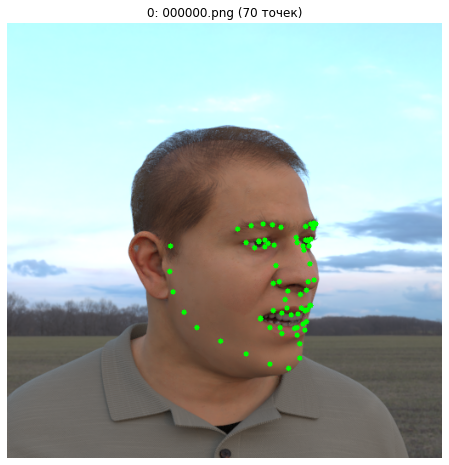

In [17]:
def visualize_landmarks(image, landmarks, title=None, point_color=(0, 255, 0), point_radius=3):

    img_copy = image.copy()
    
    for (x, y) in landmarks:
        if 0 <= x < img_copy.shape[1] and 0 <= y < img_copy.shape[0]:
            cv2.circle(img_copy, (int(x), int(y)), point_radius, point_color, -1)
    
    plt.figure(figsize=(10, 8))
    plt.imshow(img_copy)
    if title:
        plt.title(title)
    plt.axis('off')
    plt.show()

def show_img_with_landmarks(idx):
    if 0 <= idx < len(images):
        title = f"{idx}: {names[idx]} ({len(landmarks_list[idx])} точек)"
        visualize_landmarks(images[idx], landmarks_list[idx], title)
    else:
        print(f"Индекс {idx} вне диапазона (0-{len(images)-1})")

show_img_with_landmarks(0)

In [34]:
import mediapipe as mp
import cv2
import numpy as np
from scipy.spatial import KDTree

#инициализация Face Mesh
mp_face_mesh = mp.solutions.face_mesh
face_mesh = mp_face_mesh.FaceMesh(
    static_image_mode=True,
    max_num_faces=1,
    min_detection_confidence=0.5
)

def calculate_recall(gt_points, fm_points, radius=10.0):

    if len(fm_points) == 0:
        return 0.0
    
    gt_tree = KDTree(gt_points)
    
    # Определяем, какие GT точки покрыты
    gt_covered = [False] * len(gt_points)
    for fm_pt in fm_points:
        distances, idx = gt_tree.query([fm_pt])
        if distances[0] <= radius:
            gt_covered[idx[0]] = True
    
    tp = sum(gt_covered)
    recall = tp / len(gt_points) * 100
    
    return recall


num_to_evaluate = min(30, len(images))
recalls = []

for idx in range(num_to_evaluate):
    img = images[idx]
    gt_points = landmarks_list[idx]
    img_name = names[idx]
    h, w, _ = img.shape
    
    #получаем предсказания FaceMesh
    results_fm = face_mesh.process(cv2.cvtColor(img, cv2.COLOR_RGB2BGR))
    
    if results_fm.multi_face_landmarks:
        fm_points = []
        for landmark in results_fm.multi_face_landmarks[0].landmark:
            x = int(landmark.x * w)
            y = int(landmark.y * h)
            fm_points.append((x, y))
        
        recall = calculate_recall(gt_points, fm_points, radius=10)
        recalls.append(recall)
        #print(f"{idx+1:2d}. {img_name[:30]:30s} Recall: {recall:5.1f}%")
r=(np.mean(recalls)/100)
f1 = 2*p*r/(p+r) if p+r else 0
if recalls:
    #print(f"Лица обнаружены: {len(recalls)}/{num_to_evaluate}")
    print(f"Recall: {r:.3f}")
    print(f"Precision: {p:.3f}")
    print(f"F1-score: {f1:.3f}")

Recall: 0.930
Precision: 0.971
F1-score: 0.950


In [8]:
import os
import sys

#удаляем старый файл модели если он есть
if os.path.exists("face_landmarker.task"):
    os.remove("face_landmarker.task")


✅ Старая модель удалена
🔄 ПЕРЕЗАПУСТИТЕ ЯДРО Jupyter (Kernel → Restart)
   После перезапуска выполните код ниже


In [9]:
import sys
import subprocess

print("Удаляем mediapipe...")
subprocess.run([sys.executable, "-m", "pip", "uninstall", "mediapipe", "-y"])

subprocess.run([sys.executable, "-m", "pip", "cache", "purge"])

subprocess.run([sys.executable, "-m", "pip", "install", "mediapipe==0.10.8", "--no-cache-dir"])


🗑️ Удаляем mediapipe...
🧹 Очищаем кэш...
📥 Устанавливаем mediapipe...

✅ Переустановка завершена
🔄 ПЕРЕЗАПУСТИТЕ ЯДРО (Kernel → Restart)


 Название файла: 000000.png
 Размер: 512x512
✅ Найдено лиц: 1
   Всего точек: 478
   Нарисовано соединений: 2556


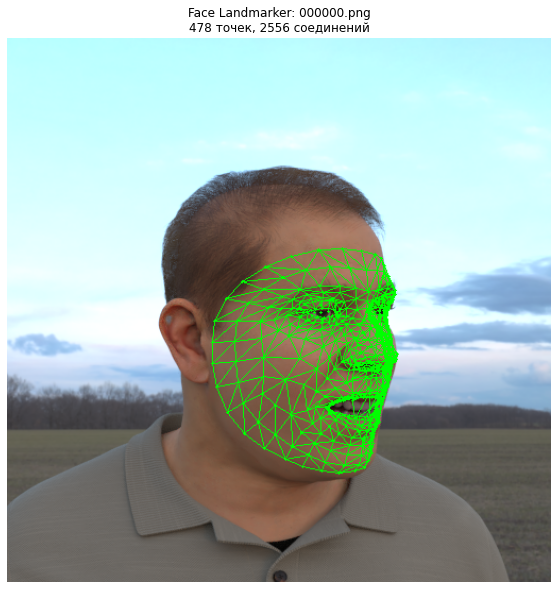


📊 Первые 10 точек (в пикселях):
--------------------------------------------------
Точка   0: x= 348, y= 331, z=-0.0276
Точка   1: x= 362, y= 304, z=-0.0607
Точка   2: x= 348, y= 313, z=-0.0313
Точка   3: x= 347, y= 280, z=-0.0586
Точка   4: x= 363, y= 296, z=-0.0644
Точка   5: x= 358, y= 286, z=-0.0606
Точка   6: x= 343, y= 263, z=-0.0353
Точка   7: x= 283, y= 259, z=-0.0700
Точка   8: x= 339, y= 247, z=-0.0305
Точка   9: x= 340, y= 238, z=-0.0349


In [10]:
import mediapipe as mp
import cv2
import matplotlib.pyplot as plt
import os

model_path = os.path.abspath("face_landmarker.task")
if not os.path.exists(model_path):
    import urllib.request
    url = "https://storage.googleapis.com/mediapipe-models/face_landmarker/face_landmarker/float16/1/face_landmarker.task"
    urllib.request.urlretrieve(url, model_path)

#инициализация Face Landmarker
options = mp.tasks.vision.FaceLandmarkerOptions(
    base_options=mp.tasks.BaseOptions(model_asset_path=model_path),
    num_faces=1,
    running_mode=mp.tasks.vision.RunningMode.IMAGE
)

detector = mp.tasks.vision.FaceLandmarker.create_from_options(options)
img = images[0]
img_name = names[0]
h, w, _ = img.shape

print(f" Название файла: {img_name}")
print(f" Размер: {w}x{h}")

mp_img = mp.Image(image_format=mp.ImageFormat.SRGB, data=img)
result = detector.detect(mp_img)

annotated_image = img.copy()

if result.face_landmarks:
    print(f" Найдено лиц: {len(result.face_landmarks)}")
    print(f"   Всего точек: {len(result.face_landmarks[0])}")
    
    face_landmarks = result.face_landmarks[0]
    for landmark in face_landmarks:
        x = int(landmark.x * w)
        y = int(landmark.y * h)
        cv2.circle(annotated_image, (x, y), 1, (0, 255, 0), -1)
    
    connections = mp.solutions.face_mesh.FACEMESH_TESSELATION
    
    for connection in connections:
        idx1, idx2 = connection
        start = face_landmarks[idx1]
        end = face_landmarks[idx2]
        x1, y1 = int(start.x * w), int(start.y * h)
        x2, y2 = int(end.x * w), int(end.y * h)
        cv2.line(annotated_image, (x1, y1), (x2, y2), (0, 255, 0), 1)
    
    print(f"   Нарисовано соединений: {len(connections)}")
else:
    print(" Лица не обнаружены")

plt.figure(figsize=(15, 10))
plt.imshow(annotated_image)
plt.title(f"Face Landmarker: {img_name}\n{len(result.face_landmarks[0]) if result.face_landmarks else 0} точек, {len(connections) if result.face_landmarks else 0} соединений")
plt.axis('off')
plt.show()

#выводим координаты первых 10 точек
if result.face_landmarks:
    print("\n Первые 10 точек (в пикселях):")
    print("-" * 50)
    for i, landmark in enumerate(result.face_landmarks[0][:10]):
        x_px = int(landmark.x * w)
        y_px = int(landmark.y * h)
        print(f"Точка {i:3d}: x={x_px:4d}, y={y_px:4d}, z={landmark.z:.4f}")

detector.close()

In [11]:
import mediapipe as mp
import cv2
import numpy as np
from scipy.spatial import KDTree
import os

model_path = os.path.abspath("face_landmarker.task")
if not os.path.exists(model_path):
    import urllib.request
    url = "https://storage.googleapis.com/mediapipe-models/face_landmarker/face_landmarker/float16/1/face_landmarker.task"
    urllib.request.urlretrieve(url, model_path)

#инициализация Face Landmarker
options = mp.tasks.vision.FaceLandmarkerOptions(
    base_options=mp.tasks.BaseOptions(model_asset_path=model_path),
    num_faces=1,
    running_mode=mp.tasks.vision.RunningMode.IMAGE
)

detector = mp.tasks.vision.FaceLandmarker.create_from_options(options)

def calculate_recall(gt_points, fm_points, radius=10.0):
    if len(fm_points) == 0:
        return 0.0
    
    gt_tree = KDTree(gt_points)
    
    gt_covered = [False] * len(gt_points)
    for fm_pt in fm_points:
        distances, idx = gt_tree.query([fm_pt])
        if distances[0] <= radius:
            gt_covered[idx[0]] = True
    
    tp = sum(gt_covered)
    recall = tp / len(gt_points) * 100
    return recall

num_to_evaluate = min(30, len(images))
recalls = []

for idx in range(num_to_evaluate):
    img = images[idx]
    gt_points = landmarks_list[idx]
    img_name = names[idx]
    h, w, _ = img.shape
    
    #получаем предсказания Face Landmarker
    mp_img = mp.Image(image_format=mp.ImageFormat.SRGB, data=img)
    result = detector.detect(mp_img)
    
    if result.face_landmarks:
        fm_points = []
        for landmark in result.face_landmarks[0]:
            x = int(landmark.x * w)
            y = int(landmark.y * h)
            fm_points.append((x, y))
        
        recall = calculate_recall(gt_points, fm_points, radius=10)
        recalls.append(recall)

detector.close()
r=(np.mean(recalls)/100)
f1 = 2*p*r/(p+r) if p+r else 0
if recalls:
    #print(f"Лица обнаружены: {len(recalls)}/{num_to_evaluate}")
    print(f"Recall: {r:.3f}")
    print(f"Precision: {p:.3f}")
    print(f"F1-score: {f1:.3f}")

Recall: 0.969
Precision: 0.982
F1-score: 0.976


In [13]:
import mediapipe as mp
import cv2
from pathlib import Path
from IPython.display import Video as IPythonVideo
import os

model_path = os.path.abspath("face_landmarker.task")
if not os.path.exists(model_path):
    import urllib.request
    url = "https://storage.googleapis.com/mediapipe-models/face_landmarker/face_landmarker/float16/1/face_landmarker.task"
    urllib.request.urlretrieve(url, model_path)

#инициализация Face Landmarker для видео
options = mp.tasks.vision.FaceLandmarkerOptions(
    base_options=mp.tasks.BaseOptions(model_asset_path=model_path),
    num_faces=5,
    running_mode=mp.tasks.vision.RunningMode.VIDEO,
    min_face_detection_confidence=0.3,   
    min_face_presence_confidence=0.5,    
    min_tracking_confidence=0.5          
)

detector = mp.tasks.vision.FaceLandmarker.create_from_options(options)

video_path = Path.cwd() / 'video2.mp4'
output_path = Path.cwd() / 'video2_output_landmarker.mp4'

if not video_path.exists():
    print(f"Видео не найдено: {video_path}")
else:
    cap = cv2.VideoCapture(str(video_path))
    
    fps = int(cap.get(cv2.CAP_PROP_FPS))
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(str(output_path), fourcc, fps, (width, height))
    
    frame_count = 0
    print("Обработка видео")
    
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break
        
        frame_count += 1
        timestamp_ms = int(frame_count * 1000 / fps)
        
        #конвертация в формат MediaPipe
        rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        mp_img = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb_frame)
        
        #получаем предсказания Face Landmarker
        result = detector.detect_for_video(mp_img, timestamp_ms)
        
        #визуализация для каждого лица
        if result.face_landmarks:
            print(f"Кадр {frame_count}: найдено {len(result.face_landmarks)} лиц")
            
            for face_idx, face_landmarks in enumerate(result.face_landmarks):
                # разные цвета для разных лиц
                colors = [(0, 255, 0), (0, 0, 255), (255, 0, 0), (255, 255, 0), (255, 0, 255)]
                color = colors[face_idx % 5]
                
                for landmark in face_landmarks:
                    x = int(landmark.x * width)
                    y = int(landmark.y * height)
                    cv2.circle(frame, (x, y), 1, color, -1)

                connections = mp.solutions.face_mesh.FACEMESH_TESSELATION
                for connection in connections:
                    idx1, idx2 = connection
                    if idx1 < len(face_landmarks) and idx2 < len(face_landmarks):
                        start = face_landmarks[idx1]
                        end = face_landmarks[idx2]
                        x1 = int(start.x * width)
                        y1 = int(start.y * height)
                        x2 = int(end.x * width)
                        y2 = int(end.y * height)
                        cv2.line(frame, (x1, y1), (x2, y2), color, 1)

                cv2.putText(frame, f"Face {face_idx+1}", (10, 30 + face_idx * 30), 
                           cv2.FONT_HERSHEY_SIMPLEX, 0.7, color, 2)
        
        out.write(frame)
        
        if frame_count % 100 == 0:
            print(f"   Обработано: {frame_count} кадров")
    
    cap.release()
    out.release()
    print(f"Видео сохранено: {output_path}")

detector.close()

Обработка видео...
Кадр 1: найдено 1 лиц
Кадр 2: найдено 1 лиц
Кадр 3: найдено 1 лиц
Кадр 4: найдено 1 лиц
Кадр 5: найдено 1 лиц
Кадр 6: найдено 1 лиц
Кадр 7: найдено 1 лиц
Кадр 8: найдено 1 лиц
Кадр 9: найдено 1 лиц
Кадр 10: найдено 1 лиц
Кадр 11: найдено 1 лиц
Кадр 12: найдено 1 лиц
Кадр 13: найдено 1 лиц
Кадр 14: найдено 1 лиц
Кадр 15: найдено 1 лиц
Кадр 16: найдено 1 лиц
Кадр 17: найдено 1 лиц
Кадр 18: найдено 1 лиц
Кадр 19: найдено 1 лиц
Кадр 20: найдено 1 лиц
Кадр 21: найдено 1 лиц
Кадр 22: найдено 1 лиц
Кадр 23: найдено 1 лиц
Кадр 24: найдено 1 лиц
Кадр 25: найдено 1 лиц
Кадр 26: найдено 1 лиц
Кадр 27: найдено 1 лиц
Кадр 28: найдено 1 лиц
Кадр 29: найдено 1 лиц
Кадр 30: найдено 1 лиц
Кадр 31: найдено 1 лиц
Кадр 32: найдено 1 лиц
Кадр 33: найдено 1 лиц
Кадр 34: найдено 1 лиц
Кадр 35: найдено 1 лиц
Кадр 36: найдено 1 лиц
Кадр 37: найдено 1 лиц
Кадр 38: найдено 1 лиц
Кадр 39: найдено 1 лиц
Кадр 40: найдено 1 лиц
Кадр 41: найдено 1 лиц
Кадр 42: найдено 1 лиц
Кадр 43: найдено 1 лиц
К